In [41]:
#Normal Imports
import requests
import pandas as pd
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

#Imports from AI
from scipy.stats import binomtest

In [63]:
#API
base = "https://play.limitlesstcg.com/api"
url = f"{base}/tournaments"

#Parameters for the API requests
params = {
    "game": "VGC",
    "limit": 50
}

response = requests.get(f"{base}/tournaments", params=params)
response.raise_for_status()

tournaments = response.json()

tournaments_df = pd.DataFrame(tournaments)

print(tournaments[0])

important_tournaments = [
    {
        "year": 2023,
        "name": "World Championships 2023",
        "vgc_id": 319
    },
    {
        "year": 2024,
        "name": "World Championships 2024",
        "vgc_id": 358
    },
    {
        "year": 2025,
        "name": "World Championships 2025",
        "vgc_id": 399
    },
    {
        "year": 2026,
        "name": "World Championships 2026",
        "vgc_id": 437
    }
]

important_tournaments_df = pd.DataFrame(
    important_tournaments
)

print(important_tournaments_df)

{'game': 'VGC', 'name': 'Cusca Champions Weekly M-C ⚡ #12 (PCVGC)', 'date': '2026-09-12T01:00:00.000Z', 'format': 'M-B', 'id': '6a8c5eb78302ae761e5fb227', 'players': 13, 'organizerId': 2512}
   year                      name  vgc_id
0  2023  World Championships 2023     319
1  2024  World Championships 2024     358
2  2025  World Championships 2025     399
3  2026  World Championships 2026     437


In [43]:
tournaments_df = pd.DataFrame(tournaments)
print(
    tournaments_df[
        ["id", "name", "date", "format", "players"]
    ].head(10)
)

                         id                                             name  \
0  6a8c5eb78302ae761e5fb227         Cusca Champions Weekly M-C ⚡ #12 (PCVGC)   
1  6aa29059ab080c8c957fff83        Pokemon Dominicana - Champions League #13   
2  6a9642f6abb948223750537b                       𝗡𝗲𝗺𝗲 𝗪𝗲𝗲𝗸𝗹𝘆 𝗠-𝐂 𝗧𝗼𝘂𝗿 🏆 #𝟕𝟏   
3  6a9f1442a4272c53be64a222      X1 Remote Battle League 8ª Edição - Reg M-C   
4  6a9b9df9a4272c53be6477a8               Friday Fight Night #72 Reg M-C Bo3   
5  6aa08a28ab080c8c957fe7e0       Devils Den Tournaments #89 | $25 For First   
6  6a9f1ef9ab080c8c957fd48f         Meeklosh's Fight Night Friday  | REG M-C   
7  6a80967b5a30714095571415   CHAMPIONS REG. M-C |👑CROWN FIGHT Bo3 TOUR #85👑   
8  6aa1245da4272c53be64b8bd               Circuito VGC #7 REG MC | Z2 Gaming   
9  6a9dded6a4272c53be649356  ⛩️Chadweezy95 VGC Champions Tournament Ep 11!⛩️   

                       date  format  players  
0  2026-09-12T01:00:00.000Z     M-B       13  
1  2026-09-12T00:00:00.00

In [44]:
min_players = 16

eligible_tournaments = tournaments_df[
    tournaments_df["players"] >= min_players
].copy()

#Sort from newest to oldest
eligible_tournaments = eligible_tournaments.sort_values(
    by="date",
    ascending=False
)
print(
    eligible_tournaments[
        ["id", "name", "date", "format", "players"]
    ].head(20)
)

                          id  \
1   6aa29059ab080c8c957fff83   
2   6a9642f6abb948223750537b   
3   6a9f1442a4272c53be64a222   
4   6a9b9df9a4272c53be6477a8   
5   6aa08a28ab080c8c957fe7e0   
6   6a9f1ef9ab080c8c957fd48f   
7   6a80967b5a30714095571415   
8   6aa1245da4272c53be64b8bd   
9   6a9dded6a4272c53be649356   
11  6a9c5238ab080c8c957fafa6   
12  6aa2cbe6a4272c53be64cf62   
13  6a9cfde3a4272c53be648a0e   
14  6aa0086fab080c8c957fdf49   
15  6a6a3192937230b102d48538   
16  6a9dbb8bab080c8c957fc227   
17  6aa1288fa4272c53be64b8e7   
18  6a9c37baa4272c53be647d8a   
19  6aa087d4a4272c53be64b3a9   
20  6a9a1587ab080c8c957f93dc   
22  6a9a185bab080c8c957f9408   

                                                 name  \
1           Pokemon Dominicana - Champions League #13   
2                          𝗡𝗲𝗺𝗲 𝗪𝗲𝗲𝗸𝗹𝘆 𝗠-𝐂 𝗧𝗼𝘂𝗿 🏆 #𝟕𝟏   
3         X1 Remote Battle League 8ª Edição - Reg M-C   
4                  Friday Fight Night #72 Reg M-C Bo3   
5          Devils Den Tournaments #89 | $2

In [45]:
#Test
tournament_id = eligible_tournaments.iloc[0]["id"]

print("Selected tournament ID:", tournament_id)

standings_url = f"{base}/tournaments/{tournament_id}/standings"

standings_response = requests.get(standings_url)

standings_response.raise_for_status()

standings = standings_response.json()

print(standings[0])

Selected tournament ID: 6aa29059ab080c8c957fff83


{'name': 'Motote', 'country': 'DO', 'decklist': [{'id': 'salamence', 'name': 'Salamence', 'item': 'Salamencite', 'ability': 'Intimidate', 'attacks': ['Hyper Voice', 'Draco Meteor', 'Tailwind', 'Protect'], 'nature': 'Modest', 'tera': None}, {'id': 'tyranitar', 'name': 'Tyranitar', 'item': 'Tyranitarite', 'ability': 'Sand Stream', 'attacks': ['Rock Slide', 'Knock Off', 'Dragon Dance', 'Protect'], 'nature': 'Adamant', 'tera': None}, {'id': 'excadrill', 'name': 'Excadrill', 'item': 'Focus Sash', 'ability': 'Sand Rush', 'attacks': ['Rock Slide', 'Earthquake', 'Iron Head', 'Protect'], 'nature': 'Adamant', 'tera': None}, {'id': 'indeedee', 'name': 'Indeedee', 'item': 'Terrain Extender', 'ability': 'Psychic Surge', 'attacks': ['Expanding Force', 'Shadow Ball', 'Encore', 'Protect'], 'nature': 'Modest', 'tera': None}, {'id': 'sneasler', 'name': 'Sneasler', 'item': 'Psychic Seed', 'ability': 'Unburden', 'attacks': ['Fake Out', 'Dire Claw', 'Close Combat', 'Protect'], 'nature': 'Adamant', 'tera': 

In [46]:
#Limitless is the guy that created the API, so we can use his decklist as a test case.
#We will see how he stores a team.
first_player = standings[0]

decklist = first_player["decklist"]

print("Decklist type:", type(decklist))
print("Decklist contents:")
print(decklist)

Decklist type: <class 'list'>
Decklist contents:
[{'id': 'salamence', 'name': 'Salamence', 'item': 'Salamencite', 'ability': 'Intimidate', 'attacks': ['Hyper Voice', 'Draco Meteor', 'Tailwind', 'Protect'], 'nature': 'Modest', 'tera': None}, {'id': 'tyranitar', 'name': 'Tyranitar', 'item': 'Tyranitarite', 'ability': 'Sand Stream', 'attacks': ['Rock Slide', 'Knock Off', 'Dragon Dance', 'Protect'], 'nature': 'Adamant', 'tera': None}, {'id': 'excadrill', 'name': 'Excadrill', 'item': 'Focus Sash', 'ability': 'Sand Rush', 'attacks': ['Rock Slide', 'Earthquake', 'Iron Head', 'Protect'], 'nature': 'Adamant', 'tera': None}, {'id': 'indeedee', 'name': 'Indeedee', 'item': 'Terrain Extender', 'ability': 'Psychic Surge', 'attacks': ['Expanding Force', 'Shadow Ball', 'Encore', 'Protect'], 'nature': 'Modest', 'tera': None}, {'id': 'sneasler', 'name': 'Sneasler', 'item': 'Psychic Seed', 'ability': 'Unburden', 'attacks': ['Fake Out', 'Dire Claw', 'Close Combat', 'Protect'], 'nature': 'Adamant', 'tera':

In [47]:
#Adding Pokemon names
pokemon_names = []

for pokemon in decklist:
    pokemon_names.append(pokemon["name"])

print(pokemon_names)

['Salamence', 'Tyranitar', 'Excadrill', 'Indeedee', 'Sneasler', 'Milotic']


In [48]:
#Create a dictionary for each player with their name, placing, and pokemon names
player_teams = []

for player in standings:

    decklist = player["decklist"]

    if decklist is None:
        continue

    pokemon_names = []

    for pokemon in decklist:
        pokemon_names.append(pokemon["name"])

    player_data = {
        "player": player["player"],
        "name": player["name"],
        "placing": player["placing"],
        "pokemon": pokemon_names
    }

    player_teams.append(player_data)

player_teams_df = pd.DataFrame(player_teams)

print(player_teams_df.head())

            player             name  placing  \
0           motote           Motote        1   
1            ban3x            Ban3x        2   
2          kardeas          Kardeas        3   
3      jeanlopez25      jeanlopez25        4   
4  lorenzo_baldera  Lorenzo_baldera        5   

                                             pokemon  
0  [Salamence, Tyranitar, Excadrill, Indeedee, Sn...  
1  [Kingambit, Sneasler, Rillaboom, Salamence, Et...  
2  [Absol, Metagross, Indeedee, Whimsicott, Sneas...  
3  [Charizard, Salamence, Aerodactyl, Sneasler, K...  
4  [Salamence, Charizard, Rillaboom, Kingambit, S...  


In [49]:
#Mid-research adjustment: The API keeps having names mismatch errors, so we are going to look for only dragon types.

DRAGON_URL = "https://pokeapi.co/api/v2/type/dragon"

response = requests.get(DRAGON_URL)
response.raise_for_status()

dragon_data = response.json()

dragon_pokemon = []

for entry in dragon_data["pokemon"]:
    dragon_pokemon.append(entry["pokemon"]["name"])

print(dragon_pokemon[:20])#Using a second API to get the types of each Pokemon

['dratini', 'dragonair', 'dragonite', 'kingdra', 'vibrava', 'flygon', 'altaria', 'bagon', 'shelgon', 'salamence', 'latias', 'latios', 'rayquaza', 'gible', 'gabite', 'garchomp', 'dialga', 'palkia', 'giratina-altered', 'axew']


In [50]:
#Create the has dragon type and dragon type count columns variables.
#if the team has a dragon type, then has_dragon = 1, else has_dragon = 0
def count_dragons(pokemon_list):

    dragon_count = 0

    for pokemon in pokemon_list:

        pokemon_name = pokemon.lower()

        if pokemon_name in dragon_pokemon:
            dragon_count += 1

    return dragon_count


player_teams_df["dragon_count"] = player_teams_df["pokemon"].apply(
    count_dragons
)

player_teams_df["has_dragon"] = (
    player_teams_df["dragon_count"] > 0
).astype(int)


print(
    player_teams_df[
        ["name", "pokemon", "dragon_count", "has_dragon"]
    ].head(10)
)

              name                                            pokemon  \
0           Motote  [Salamence, Tyranitar, Excadrill, Indeedee, Sn...   
1            Ban3x  [Kingambit, Sneasler, Rillaboom, Salamence, Et...   
2          Kardeas  [Absol, Metagross, Indeedee, Whimsicott, Sneas...   
3      jeanlopez25  [Charizard, Salamence, Aerodactyl, Sneasler, K...   
4  Lorenzo_baldera  [Salamence, Charizard, Rillaboom, Kingambit, S...   
5         el poeta  [Kingambit, Rillaboom, Salamence, Floette, Inc...   
6            IvaSS  [Lucario, Armarouge, Torkoal, Alakazam, Indeed...   
7         rickinch  [Rillaboom, Primarina, Volcarona, Lucario, Sal...   
8     Itswayne1699  [Indeedee ♀, Vileplume, Armarouge, Torkoal, Ma...   
9             Humi  [Pelipper, Archaludon, Golisopod, Sneasler, Ri...   

   dragon_count  has_dragon  
0             1           1  
1             1           1  
2             0           0  
3             2           1  
4             1           1  
5             1 

In [51]:
#Pulling data from the actual tournaments.
pairings_url = f"{base}/tournaments/{tournament_id}/pairings"

pairings_response = requests.get(pairings_url)
pairings_response.raise_for_status()

pairings = pairings_response.json()

pairings_df = pd.DataFrame(pairings)

print(
    pairings_df[
        ["round", "phase", "player1", "player2", "winner"]
    ].head(10)
)

   round  phase          player1      player2           winner
0      1      1       apolobill1          NaN               -1
1      1      1          gabbvgc     rickinch         rickinch
2      1      1         poetin05  jeanlopez25      jeanlopez25
3      1      1          raven3d      kardeas          kardeas
4      1      1     itswayne1699      mariosr     itswayne1699
5      1      1      frankbaez77        kayge            kayge
6      1      1  lorenzo_baldera      marioha  lorenzo_baldera
7      1      1           motote        ivass           motote
8      1      1             humi   dokkatoast             humi
9      1      1       engers1619        ban3x            ban3x


In [52]:
#Merge the dragon data with the tournament matches data.
player_dragon_info = player_teams_df[
    ["player", "has_dragon", "dragon_count"]
]

matches_df = pairings_df.merge(
    player_dragon_info,
    left_on="player1",
    right_on="player",
    how="left"
)

matches_df = matches_df.rename(
    columns={
        "has_dragon": "player1_has_dragon",
        "dragon_count": "player1_dragon_count"
    }
)

matches_df = matches_df.drop(columns=["player"])

matches_df = matches_df.merge(
    player_dragon_info,
    left_on="player2",
    right_on="player",
    how="left"
)

matches_df = matches_df.rename(
    columns={
        "has_dragon": "player2_has_dragon",
        "dragon_count": "player2_dragon_count"
    }
)

matches_df = matches_df.drop(columns=["player"])


print(
    matches_df[
        [
            "round",
            "player1",
            "player1_has_dragon",
            "player2",
            "player2_has_dragon",
            "winner"
        ]
    ].head(10)
)

   round          player1  player1_has_dragon      player2  \
0      1       apolobill1                   1          NaN   
1      1          gabbvgc                   1     rickinch   
2      1         poetin05                   1  jeanlopez25   
3      1          raven3d                   1      kardeas   
4      1     itswayne1699                   0      mariosr   
5      1      frankbaez77                   0        kayge   
6      1  lorenzo_baldera                   1      marioha   
7      1           motote                   1        ivass   
8      1             humi                   1   dokkatoast   
9      1       engers1619                   1        ban3x   

   player2_has_dragon           winner  
0                 NaN               -1  
1                 1.0         rickinch  
2                 1.0      jeanlopez25  
3                 0.0          kardeas  
4                 1.0     itswayne1699  
5                 1.0            kayge  
6                 1.0  lorenzo

In [53]:
#Calculating the raw win stats for analysis.
def player1_result(row):

    if row["winner"] == row["player1"]:
        return 1

    elif row["winner"] == row["player2"]:
        return 0

    else:
        return None


def player2_result(row):

    if row["winner"] == row["player2"]:
        return 1

    elif row["winner"] == row["player1"]:
        return 0

    else:
        return None


matches_df["player1_won"] = matches_df.apply(
    player1_result,
    axis=1
)

matches_df["player2_won"] = matches_df.apply(
    player2_result,
    axis=1
)


print(
    matches_df[
        [
            "player1",
            "player1_has_dragon",
            "player1_won",
            "player2",
            "player2_has_dragon",
            "player2_won",
            "winner"
        ]
    ].head(10)
)

           player1  player1_has_dragon  player1_won      player2  \
0       apolobill1                   1          NaN          NaN   
1          gabbvgc                   1          0.0     rickinch   
2         poetin05                   1          0.0  jeanlopez25   
3          raven3d                   1          0.0      kardeas   
4     itswayne1699                   0          1.0      mariosr   
5      frankbaez77                   0          0.0        kayge   
6  lorenzo_baldera                   1          1.0      marioha   
7           motote                   1          1.0        ivass   
8             humi                   1          1.0   dokkatoast   
9       engers1619                   1          0.0        ban3x   

   player2_has_dragon  player2_won           winner  
0                 NaN          NaN               -1  
1                 1.0          1.0         rickinch  
2                 1.0          1.0      jeanlopez25  
3                 0.0          1.0 

In [54]:
#Match data cleaning from AI. 


clean_matches_df = matches_df.copy()

clean_matches_df = clean_matches_df.dropna(
    subset=[
        "player1_has_dragon",
        "player2_has_dragon",
        "player1_won",
        "player2_won"
    ]
)

clean_matches_df = clean_matches_df[
    ~clean_matches_df["winner"].isin(["0", "-1", 0, -1])
]

clean_matches_df = clean_matches_df.reset_index(drop=True)

print("Original matches:", len(matches_df))
print("Clean matches:", len(clean_matches_df))

print(
    clean_matches_df[
        [
            "round",
            "player1",
            "player1_has_dragon",
            "player1_won",
            "player2",
            "player2_has_dragon",
            "player2_won",
            "winner"
        ]
    ].head(10)
)

Original matches: 40
Clean matches: 36
   round          player1  player1_has_dragon  player1_won      player2  \
0      1          gabbvgc                   1          0.0     rickinch   
1      1         poetin05                   1          0.0  jeanlopez25   
2      1          raven3d                   1          0.0      kardeas   
3      1     itswayne1699                   0          1.0      mariosr   
4      1      frankbaez77                   0          0.0        kayge   
5      1  lorenzo_baldera                   1          1.0      marioha   
6      1           motote                   1          1.0        ivass   
7      1             humi                   1          1.0   dokkatoast   
8      1       engers1619                   1          0.0        ban3x   
9      2  lorenzo_baldera                   1          0.0        ban3x   

   player2_has_dragon  player2_won           winner  
0                 1.0          1.0         rickinch  
1                 1.0      

In [55]:
#Calculating the win rates for analysis.
#Teams that have dragon types vs non-dragon types teams.
player1_data = clean_matches_df[
    ["player1_has_dragon", "player1_won"]
].copy()

player1_data.columns = ["has_dragon", "won"]


player2_data = clean_matches_df[
    ["player2_has_dragon", "player2_won"]
].copy()

player2_data.columns = ["has_dragon", "won"]


# Combine both sides of every match
analysis_df = pd.concat(
    [player1_data, player2_data],
    ignore_index=True
)


# Calculate results
win_rates = analysis_df.groupby("has_dragon").agg(
    matches=("won", "count"),
    wins=("won", "sum"),
    win_rate=("won", "mean")
).reset_index()


# Convert win rate to percentage
win_rates["win_rate_percent"] = (
    win_rates["win_rate"] * 100
)


print(win_rates)

   has_dragon  matches  wins  win_rate  win_rate_percent
0         0.0       22  12.0  0.545455         54.545455
1         1.0       50  24.0  0.480000         48.000000


In [56]:
#Statistical Tests for significance of the win rates.
from scipy.stats import binomtest


# Keep only matches where exactly one team has a Dragon type
dragon_vs_no_dragon = clean_matches_df[
    clean_matches_df["player1_has_dragon"]
    != clean_matches_df["player2_has_dragon"]
].copy()


# Determine whether the Dragon team won
def dragon_team_result(row):

    if row["player1_has_dragon"] == 1:
        return row["player1_won"]

    else:
        return row["player2_won"]


dragon_vs_no_dragon["dragon_team_won"] = (
    dragon_vs_no_dragon.apply(
        dragon_team_result,
        axis=1
    )
)


# Count wins and total matches
dragon_wins = int(
    dragon_vs_no_dragon["dragon_team_won"].sum()
)

total_matches = len(dragon_vs_no_dragon)

dragon_losses = total_matches - dragon_wins


# Calculate win rate
dragon_win_rate = dragon_wins / total_matches


# Run binomial test
test_result = binomtest(
    k=dragon_wins,
    n=total_matches,
    p=0.50
)


print("Dragon vs No-Dragon matches:", total_matches)
print("Dragon wins:", dragon_wins)
print("Dragon losses:", dragon_losses)

print(
    "Dragon win rate:",
    round(dragon_win_rate * 100, 2),
    "%"
)

print("P-value:", test_result.pvalue)

Dragon vs No-Dragon matches: 16
Dragon wins: 7
Dragon losses: 9
Dragon win rate: 43.75 %
P-value: 0.803619384765625


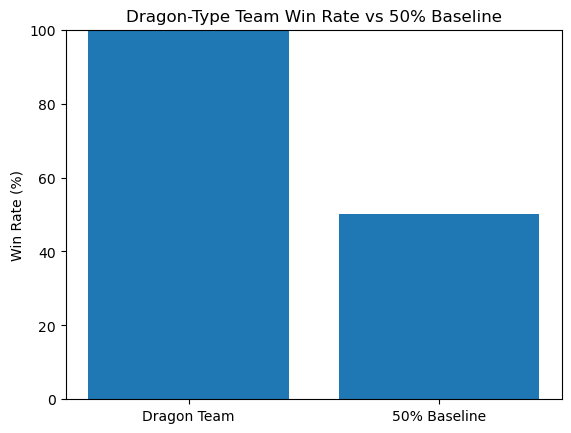

<Figure size 640x480 with 0 Axes>

In [69]:
#Data Visualization for the win rates of dragon type teams vs non-dragon type teams.
import matplotlib.pyplot as plt

#Bar graph comparing the win rates of Dragon-type teams vs a 50% baseline.
categories = ["Dragon Team", "50% Baseline"]

values = [
    dragon_win_rate * 100,
    50
]


plt.bar(categories, values)

plt.ylabel("Win Rate (%)")
plt.title("Dragon-Type Team Win Rate vs 50% Baseline")

plt.ylim(0, 100)

plt.show()
plt.savefig("dragon-win-rate.png", bbox_inches="tight")



In [67]:
#Line chart showing the win rates of Dragon-type teams over the rounds of the tournament.tournament_results = []

tournament_usage = []

# Start with the first 10 eligible tournaments
for _, tournament in eligible_tournaments.head(10).iterrows():

    tournament_id = tournament["id"]
    tournament_name = tournament["name"]

    standings_url = f"{base}/tournaments/{tournament_id}/standings"

    response = requests.get(standings_url)
    response.raise_for_status()

    standings = response.json()

    total_teams = 0
    dragon_teams = 0

    for player in standings:

        decklist = player["decklist"]

        # Skip players without a teamlist
        if decklist is None:
            continue

        pokemon_names = []

        for pokemon in decklist:
            pokemon_names.append(pokemon["name"].lower())

        total_teams += 1

        # Check if at least one Pokemon is Dragon type
        has_dragon = False

        for pokemon in pokemon_names:
            if pokemon in dragon_pokemon:
                has_dragon = True
                break

        if has_dragon:
            dragon_teams += 1

    # Only calculate if teamlists were available
    if total_teams > 0:

        usage_rate = (dragon_teams / total_teams) * 100

        tournament_usage.append({
            "tournament": tournament_name,
            "total_teams": total_teams,
            "dragon_teams": dragon_teams,
            "dragon_usage_rate": usage_rate
        })


# Turn results into a DataFrame
dragon_usage_df = pd.DataFrame(tournament_usage)

print(dragon_usage_df)

                                        tournament  total_teams  dragon_teams  \
0        Pokemon Dominicana - Champions League #13           19            14   
1                       𝗡𝗲𝗺𝗲 𝗪𝗲𝗲𝗸𝗹𝘆 𝗠-𝐂 𝗧𝗼𝘂𝗿 🏆 #𝟕𝟏           43            32   
2      X1 Remote Battle League 8ª Edição - Reg M-C           18            13   
3               Friday Fight Night #72 Reg M-C Bo3           30            23   
4       Devils Den Tournaments #89 | $25 For First          177           129   
5         Meeklosh's Fight Night Friday  | REG M-C           42            28   
6   CHAMPIONS REG. M-C |👑CROWN FIGHT Bo3 TOUR #85👑          150           114   
7               Circuito VGC #7 REG MC | Z2 Gaming           19             9   
8  ⛩️Chadweezy95 VGC Champions Tournament Ep 11!⛩️           24            16   
9                              SNT Reg M-C Tour #1           47            30   

   dragon_usage_rate  
0          73.684211  
1          74.418605  
2          72.222222  
3          76.66

C:\Users\bella\AppData\Local\Temp\ipykernel_26724\3721186805.py:17: UserWarning: Glyph 120289 (\N{MATHEMATICAL SANS-SERIF BOLD CAPITAL N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_26724\3721186805.py:17: UserWarning: Glyph 120306 (\N{MATHEMATICAL SANS-SERIF BOLD SMALL E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_26724\3721186805.py:17: UserWarning: Glyph 120314 (\N{MATHEMATICAL SANS-SERIF BOLD SMALL M}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_26724\3721186805.py:17: UserWarning: Glyph 120298 (\N{MATHEMATICAL SANS-SERIF BOLD CAPITAL W}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_26724\3721186805.py:17: UserWarning: Glyph 120312 (\N{MATHEMATICAL SANS-SERIF BOLD SMALL K}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ip

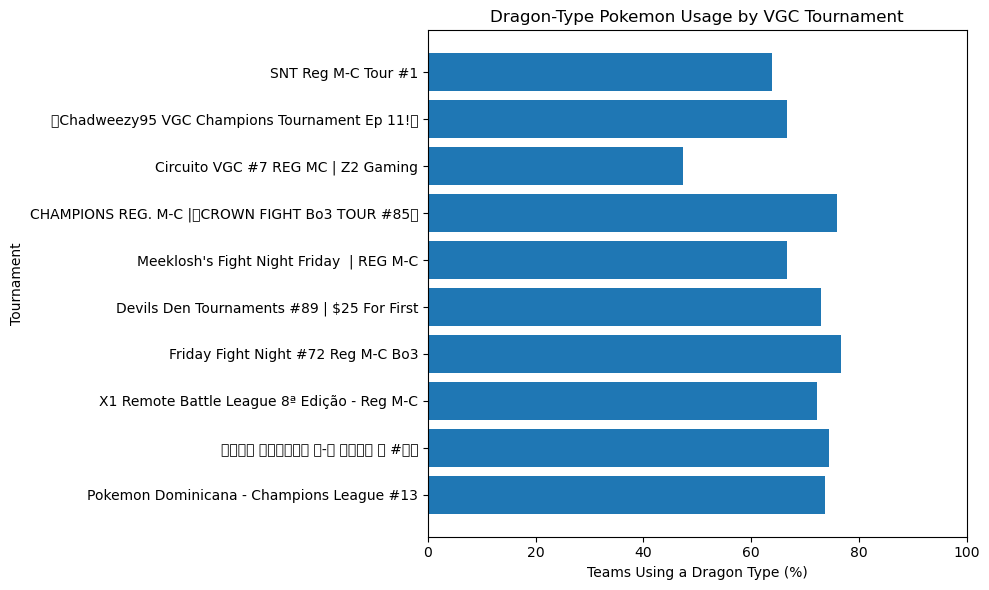

<Figure size 640x480 with 0 Axes>

In [70]:
#Line Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    dragon_usage_df["tournament"],
    dragon_usage_df["dragon_usage_rate"]
)

plt.xlabel("Teams Using a Dragon Type (%)")
plt.ylabel("Tournament")
plt.title("Dragon-Type Pokemon Usage by VGC Tournament")

plt.xlim(0, 100)

plt.tight_layout()

plt.show()
plt.savefig("dragon_type_win_rates_tournaments", bbox_inches="tight")